In [13]:
import numpy as np
import pandas as pd
import scanpy as sc
import gseapy as gp
import matplotlib.pyplot as plt
import warnings
import os
import pertpy as pt
import decoupler as dc
import subprocess

warnings.simplefilter(action="ignore", category=Warning)

In [4]:
gp.__version__

'1.1.11'

In [ ]:
endo_ann = sc.read("endo_scvi_annotated.h5ad")

In [9]:
pdata = sc.read("pdata.h5ad")

In [10]:
stroma = pdata[pdata.obs["cell_type"] == "eStroma"].copy()

In [11]:
dc.pp.filter_by_expr(
    adata=stroma,
    group="Status",
    min_count=10,
    min_total_count=15,
    large_n=10,
    min_prop=0.7,
)
dc.pp.filter_by_prop(
    adata=stroma,
    min_prop=0.1,
    min_smpls=2,
)
stroma

AnnData object with n_obs × n_vars = 7 × 716
    obs: 'Donor', 'cell_type', 'predicted_doublet', 'Status', 'Phase', 'Study', 'Instrument', '_scvi_batch', '_scvi_labels', 'leiden_0_25', 'psbulk_cells', 'psbulk_counts'
    var: 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'mean', 'std'
    uns: 'log1p', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'X', 'counts', 'psbulk_props'

In [14]:
stroma_pds2 = pt.tl.PyDESeq2(adata=stroma, design="~Status")

In [15]:
stroma_pds2.fit()

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 0.21 seconds.

Fitting dispersion trend curve...
... done in 0.03 seconds.

Fitting MAP dispersions...
... done in 0.44 seconds.

Fitting LFCs...
... done in 0.18 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.



In [16]:
stroma_df = stroma_pds2.test_contrasts(stroma_pds2.contrast(column="Status", baseline="Control", group_to_compare="Thin"))

Running Wald tests...
... done in 0.17 seconds.



Log2 fold change & Wald test p-value, contrast vector: [0. 1.]
           baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
VWA1     291.374629       -0.505064  0.764093 -0.660998  0.508614  0.674401
ERRFI1  4774.470138        0.023996  0.698628  0.034347  0.972600  0.985069
HSPG2   1314.462064       -0.403308  0.499643 -0.807191  0.419556  0.601421
ID3     5190.055375       -0.953681  0.661748 -1.441153  0.149541  0.323173
SFN       90.043776       -1.948392  1.364249 -1.428180  0.153240  0.326209
...             ...             ...       ...       ...       ...       ...
FGF13   5255.314009        0.785612  0.408484  1.923240  0.054450  0.164740
CETN2   1819.150681        0.598465  0.487385  1.227911  0.219480  0.405326
BGN      666.905353        1.107289  0.616782  1.795268  0.072611  0.199330
CLIC2    672.141125        0.308339  0.509282  0.605439  0.544887  0.701838
TTTY14   442.764606       -1.853476  1.219401 -1.519990  0.128514  0.293804

[716 rows x 6 columns]


In [18]:
stroma_dge_df = stroma_df[stroma_df['adj_p_value'] < 0.05]

In [27]:
stroma_dge_df

,variable,baseMean,log_fc,lfcSE,stat,p_value,adj_p_value,contrast
0,TULP2,1378.593241,-5.169295,0.594437,-8.696125,3.434116e-18,2.441657e-15,None
1,ATCAY,276.992509,-5.268548,0.735668,-7.161584,7.975018e-13,2.835119e-10,None
2,ENSG00000267011,215.080048,-3.935703,0.560163,-7.025998,2.125417e-12,5.037237e-10,None
3,RAD54L,250.898361,-3.453882,0.527893,-6.542771,6.038944e-11,1.073422e-08,None
4,CRIP1,1358.655926,-2.711589,0.440470,-6.156124,7.454701e-10,1.060058e-07,None
...,...,...,...,...,...,...,...,...
127,SFRP4,113898.519469,2.459349,0.928480,2.648790,8.078062e-03,4.465475e-02,None
128,H1-3,181.910252,1.516256,0.572649,2.647793,8.101917e-03,4.465475e-02,None
129,CCBE1,5614.144130,2.200766,0.841390,2.615631,8.906272e-03,4.871046e-02,None
130,LAMA3,2851.051631,2.197726,0.844219,2.603265,9.234068e-03,4.995291e-02,None


In [32]:
gp.get_library_name()

['ARCHS4_Cell-lines',
 'ARCHS4_IDG_Coexp',
 'ARCHS4_Kinases_Coexp',
 'ARCHS4_TFs_Coexp',
 'ARCHS4_Tissues',
 'Achilles_fitness_decrease',
 'Achilles_fitness_increase',
 'Aging_Perturbations_from_GEO_down',
 'Aging_Perturbations_from_GEO_up',
 'Allen_Brain_Atlas_10x_scRNA_2021',
 'Allen_Brain_Atlas_down',
 'Allen_Brain_Atlas_up',
 'Azimuth_2023',
 'Azimuth_Cell_Types_2021',
 'BioCarta_2013',
 'BioCarta_2015',
 'BioCarta_2016',
 'BioPlanet_2019',
 'BioPlex_2017',
 'BrainRanger_Regions_ARCHS4_2026',
 'CCLE_Proteomics_2020',
 'CM4AI_U2OS_Protein_Localization_Assemblies',
 'COMPARTMENTS_Curated_2025',
 'COMPARTMENTS_Experimental_2025',
 'CORUM',
 'COVID-19_Related_Gene_Sets',
 'COVID-19_Related_Gene_Sets_2021',
 'Cancer_Cell_Line_Encyclopedia',
 'Carcinogenome',
 'CellMarker_2024',
 'CellMarker_Augmented_2021',
 'ChEA_2013',
 'ChEA_2015',
 'ChEA_2016',
 'ChEA_2022',
 'Chromosome_Location',
 'Chromosome_Location_hg19',
 'ClinVar_2019',
 'ClinVar_2025',
 'DGIdb_Drug_Targets_2024',
 'DSigDB',


In [37]:
pre_res_pseudo = gp.prerank(stroma_dge_df.loc[:, ["variable", "log_fc"]], 
                            gene_sets = 'Reactome_Pathways_20254', 
                            seed=42, 
                            min_size = 5,
                            max_size = 1000,
                            permutation_num = 1000)

In [38]:
prerank_df = pre_res_pseudo.res2d

In [39]:
prerank_df.head(50)

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,Receptor Ligand Activity (GO:0048018),-0.636904,-1.469095,0.063309,0.133044,0.100327,3/5,12.12%,CXCL13;DKK1;IL6
1,prerank,Protein Homodimerization Activity (GO:0042803),-0.473335,-1.098026,0.329942,0.331887,0.44711,3/5,29.55%,ZBTB16;S100A10;MME


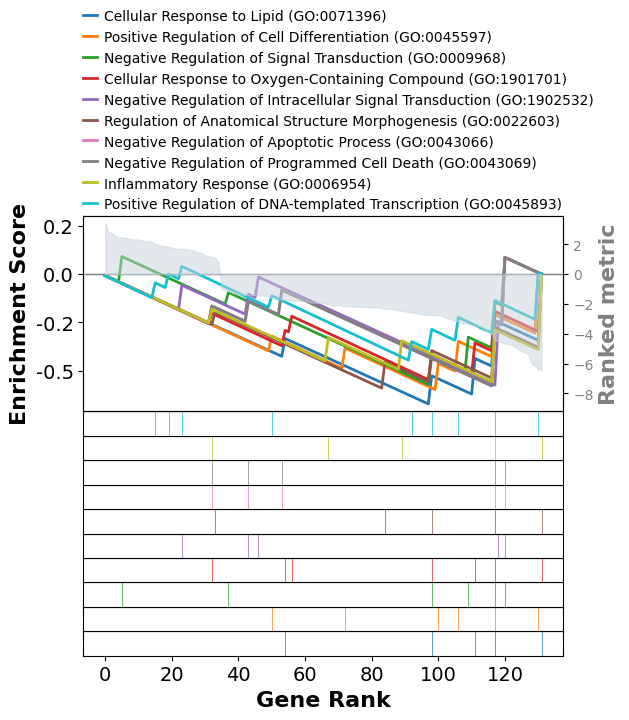

In [36]:
term2 = pre_res_pseudo.res2d.Term
axes = pre_res_pseudo.plot(terms=term2[:10])
#axes.savefig('stroma_gsea_plot.png', dpi=300, bbox_inches='tight')